# This example comes from
https://github.com/adjtomo/adjdocs/blob/main/workshops/2024-05-21_scoped_uw/3_adjoint_simulations.ipynb

In [12]:
# Python packages we will use in this notebook
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
from scipy.integrate import simpson
from seisflows.tools.model import Model 
np.float_ = np.float64
from pyatoa import Config, Manager, logger
from pysep.utils.io import read_sem
import pandas as pd
import pickle as pkl
import pyfm2d
from scipy.interpolate import RectBivariateSpline
import datetime

In [2]:
def make_nodes_4_checkerboard(nodex=4,nodey=4, amp=1):
    check_arr = []
    for i_y in range(nodey):
        row=[]
        for i_x in range(nodex):
            if i_y%2 == 0:
                if i_x%2 == 0:
                    row.append(1)
                else:
                    row.append(-1)
            else:
                if i_x%2 == 0:
                    row.append(-1)
                else:
                    row.append(1)
        check_arr.append(row)
    return np.array(check_arr).T*amp

In [3]:
# Make correct dir. and move there
! mkdir -p /home/scoped/work/kernels
%cd /home/scoped/work/kernels

# Symlink the executables and copy the relevant DATA/ directory
! ln -s /home/scoped/specfem2d_eastwind/bin .
! cp -r /home/scoped/specfem2d_eastwind/EXAMPLES/eastwind/DATA .
! mkdir OUTPUT_FILES_EASTWIND

! ls

/home/scoped/work/kernels
ln: failed to create symbolic link './bin': File exists
mkdir: cannot create directory ‘OUTPUT_FILES_EASTWIND’: File exists
AA.S000000.BXY.png  EW.C0000.BXY.png	   OUTPUT_FILES_INIT
bin		    OUTPUT_FILES	   OUTPUT_FILES_TRUE
DATA		    OUTPUT_FILES_EASTWIND  SEM


In [4]:
# Incase participants get lost, each numbered section 
# contains the absolute work dir path
%cd /home/scoped/work/kernels

/home/scoped/work/kernels


## Make the mesh

#### Load the cable location

In [5]:
channel_locations = np.array(pd.read_csv('/home/scoped/eastwind_v2/cable_geometry/Eastwind_channel_locations.txt', sep=' ', header=None))

#### Load the source locations

In [6]:
with open('/home/scoped/eastwind_v2/event_locations/good_event_locations.pkl', 'rb') as f:
    all_locations_good = pkl.load(f)
mean_params_good = np.mean(np.array(list(all_locations_good.values())),axis=1)
std_params_good = np.std(np.array(list(all_locations_good.values())),axis=1)

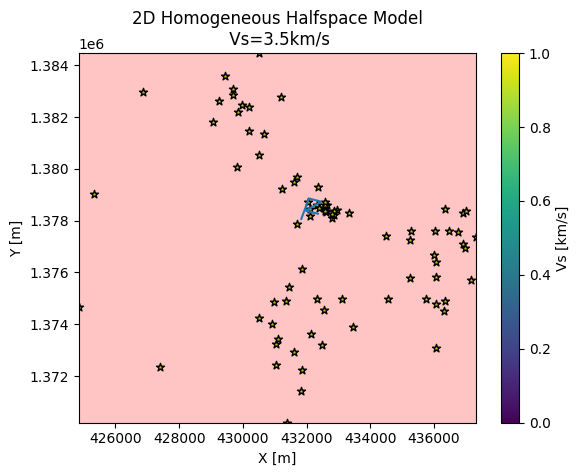

In [7]:
def plot_homogeneous_halfspace():
    """
    Plots a representation of the SPECFEM2D 
    homogeneous halfspace model
    """
    # Sets the X and Z dimensions of our mesh
    xmax = mean_params_good[:,0].max()
    xmin = mean_params_good[:,0].min()
    ymax = mean_params_good[:,1].max()
    ymin = mean_params_good[:,1].min()

    mesh_res = 100
    nx = int((xmax - xmin)/mesh_res)
    ny = int((ymax - ymin)/mesh_res)
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    
    # Reformat the 1D arrays into 2D
    xv, yv = np.meshgrid(x, y)

    # Set a homogeneous value of Vs=3.5km/s 
    vs = 3.5 * np.ones(np.shape(xv))

    # Plot the arrays as a homogeneous halfspace
    plt.tricontourf(xv.flatten(), yv.flatten(), vs.flatten(), 
                    cmap="seismic_r", vmin=3.1, vmax=4.)
    
    plt.plot(channel_locations[:,0], channel_locations[:,1])
    plt.scatter(mean_params_good[:,0], mean_params_good[:,1], c="y", marker="*", ec='black')
    plt.colorbar(label="Vs [km/s]", format="%.1f")
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.title("2D Homogeneous Halfspace Model\n Vs=3.5km/s")
    
# Calls the function we just defined
plot_homogeneous_halfspace()

## Make a checkerboard velocity model

In [8]:
# Get the domain extent
xmax = mean_params_good[:,0].max()
xmin = mean_params_good[:,0].min()
ymax = mean_params_good[:,1].max()
ymin = mean_params_good[:,1].min()

mesh_res = 1000
nx = int((xmax - xmin)/mesh_res)
ny = int((ymax - ymin)/mesh_res)
x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)

# Reformat the 1D arrays into 2D
xv, yv = np.meshgrid(x, y)

In [9]:
with open('DATA/Par_file_Eastwindrec_checker', "r") as f:
    lines = f.readlines()


lines[292] = '1 1 917.d0 3600.d0 1800.0d0 0 0 10.d0 10.d0 0 0 0 0 0 0\n'
lines[298] = 'xmin                            = '+str(xmin)+'d0           # abscissa of left side of the model\n'
lines[299] = 'xmax                            = '+str(xmax)+'d0           # abscissa of right side of the model\n'
lines[300] = 'nx                              = '+str(nx)+'                        # number of elements along X\n'
lines[301] = 'nx                              = '+str(ny)+'                        # number of elements along X\n'
lines[312] = '1 '+str(nx)+'  1 '+str(ny)+' 1\n'


with open('DATA/Par_file_Eastwindrec_checker_updated', "w") as output:
    output.writelines(lines)

In [10]:
nodex = 4
nodey = 4


ms = make_nodes_4_checkerboard(nodex=nodex, nodey=nodey,amp=.1)
mp = make_nodes_4_checkerboard(nodex=nodex, nodey=nodey,amp=.2)

In [11]:
gs = pyfm2d.BasisModel(ms, extent=[xmin, xmax, ymin, ymax])
gp = pyfm2d.BasisModel(mp, extent=[xmin, xmax, ymin, ymax])

In [12]:
mps = gs.get_velocity()
gs.set_velocity(mps)
gs.get_slowness()

mpp = gp.get_velocity()
gp.set_velocity(mpp)
gp.get_slowness()

array([[ 5., -5.,  5., -5.],
       [-5.,  5., -5.,  5.],
       [ 5., -5.,  5., -5.],
       [-5.,  5., -5.,  5.]])

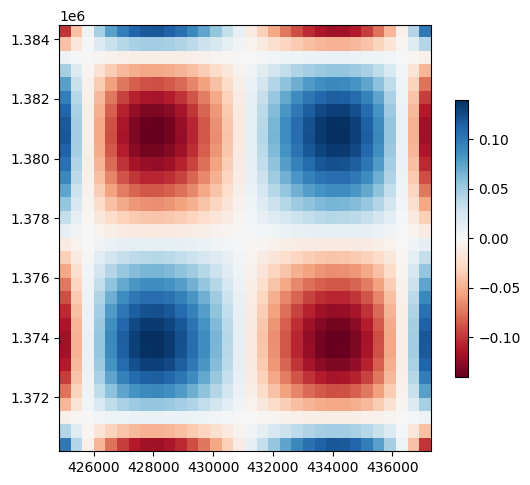

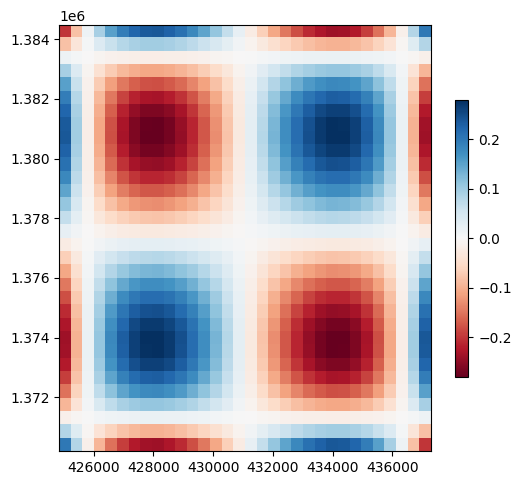

In [13]:
velocity_s = gs.get_velocity()
velocity_p = gp.get_velocity()
im = pyfm2d.display_model(velocity_s, extent=[xmin, xmax, ymin, ymax])
im = pyfm2d.display_model(velocity_p, extent=[xmin, xmax, ymin, ymax])

## Resample to our mesh domain

In [14]:
x_check = np.linspace(xmin,xmax,velocity_s.shape[0])
y_check = np.linspace(ymin,ymax,velocity_s.shape[1])

rects = RectBivariateSpline(x_check, y_check, velocity_s, kx=3, ky=3)
vel_model_s = rects.ev(xv, yv) + 1.8

rectp = RectBivariateSpline(x_check, y_check, velocity_p, kx=3, ky=3)
vel_model_p = rectp.ev(xv, yv) + 3.6

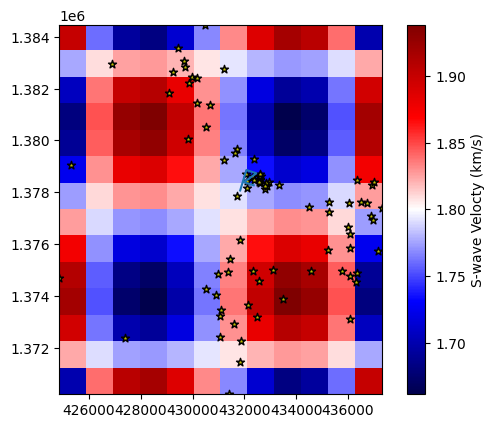

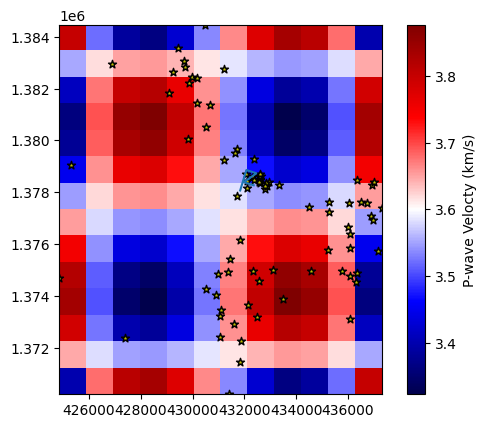

In [15]:
fig,ax = plt.subplots()
im_s = plt.imshow(vel_model_s, extent=[xmin, xmax, ymin, ymax], cmap='seismic')
plt.plot(channel_locations[:,0], channel_locations[:,1])
plt.scatter(mean_params_good[:,0], mean_params_good[:,1], c="y", marker="*", ec='black')
plt.colorbar(im_s, label='S-wave Velocty (km/s)')

fig,ax = plt.subplots()
im_p = plt.imshow(vel_model_p, extent=[xmin, xmax, ymin, ymax], cmap='seismic')
plt.plot(channel_locations[:,0], channel_locations[:,1])
plt.scatter(mean_params_good[:,0], mean_params_good[:,1], c="y", marker="*", ec='black')
plt.colorbar(im_p, label='P-wave Velocty (km/s)')

In [16]:
nx_elem = nx
ny_elem = ny
NGLL = 5

dx = (xmax - xmin) / nx_elem
dy = (ymax - ymin) / ny_elem

# 5-point GLL nodes
gll = np.array([-1.0, -0.6546536707079771, 0.0,
                0.6546536707079771, 1.0])

npoints = nx_elem * ny_elem * NGLL * NGLL
xv = np.empty(npoints)
yv = np.empty(npoints)

k = 0
for ey in range(ny_elem):
    y0 = ymin + ey*dy
    y1 = y0 + dy
    for ex in range(nx_elem):
        x0 = xmin + ex*dx
        x1 = x0 + dx
        for j in range(NGLL):
            y = 0.5*((1-gll[j])*y0 + (1+gll[j])*y1)
            for i in range(NGLL):
                x = 0.5*((1-gll[i])*x0 + (1+gll[i])*x1)
                xv[k] = x
                yv[k] = y
                k += 1

vel_model_s = rects.ev(xv, yv) + 1.8
vel_model_p = rectp.ev(xv, yv) + 3.6

In [17]:
velocity_model_checkerboard = {
    'x':xv.flatten(),
    'y':yv.flatten(),
    'rho':[917.]*len(yv.flatten()),
    'vp':vel_model_p.flatten()*1000,
    'vs':vel_model_s.flatten()*1000,
}

velocity_model_checkerboard_frame = pd.DataFrame(velocity_model_checkerboard)
velocity_model_checkerboard_frame.to_csv('/home/scoped/work/kernels/DATA/model_velocity_eastwind.dat_checker',header=False, index=True, float_format='%.4f', sep ='\t')
velocity_model_checkerboard_frame.to_csv('/home/scoped/specfem2d_eastwind/EXAMPLES/eastwind/DATA/model_velocity_eastwind.dat_checker',header=False, index=True, float_format='%.4f', sep ='\t')

In [18]:
# Look at the first few lines of the checkerboard model
! head DATA/model_velocity_eastwind.dat_checker


0	424851.0794	1370195.3543	917.0000	3800.0000	1900.0000
1	425030.3630	1370195.3543	917.0000	3744.6570	1872.3285
2	425370.2207	1370195.3543	917.0000	3651.5625	1825.7812
3	425710.0785	1370195.3543	917.0000	3573.2001	1786.6001
4	425889.3621	1370195.3543	917.0000	3537.5000	1768.7500
5	424851.0794	1370371.3877	917.0000	3752.2942	1876.1471
6	425030.3630	1370371.3877	917.0000	3710.1521	1855.0761
7	425370.2207	1370371.3877	917.0000	3639.2634	1819.6317
8	425710.0785	1370371.3877	917.0000	3579.5927	1789.7963
9	425889.3621	1370371.3877	917.0000	3552.4081	1776.2040


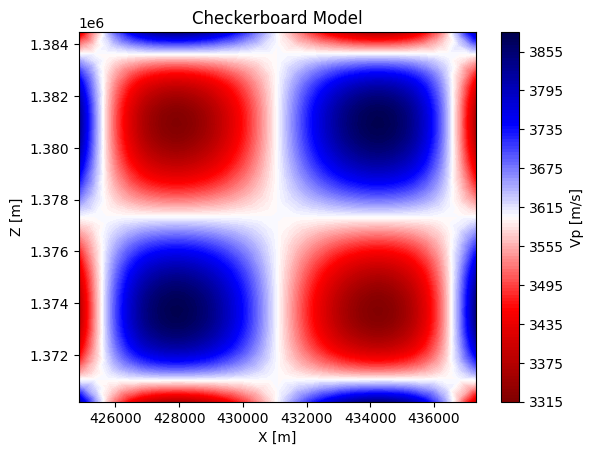

In [19]:
# Grab values of X, Z, Vs and Vp for plotting
dummy_indices ,chkbd_x, chkbd_y, chkbd_rho, chkbd_vp, chkbd_vs = np.genfromtxt("DATA/model_velocity_eastwind.dat_checker", dtype=float, delimiter='\t', ).T


def plot_checkerboard(x, y, c, label, alpha=1):
    """Simple re-usable model plotting function"""
    plt.tricontourf(x, y, c, levels=125, cmap="seismic_r", alpha=alpha)
    plt.xlabel("X [m]")
    plt.ylabel("Z [m]")
    plt.title("Checkerboard Model")
    plt.colorbar(label=label)
    
plot_checkerboard(chkbd_x, chkbd_y, chkbd_vp, label="Vp [m/s]")



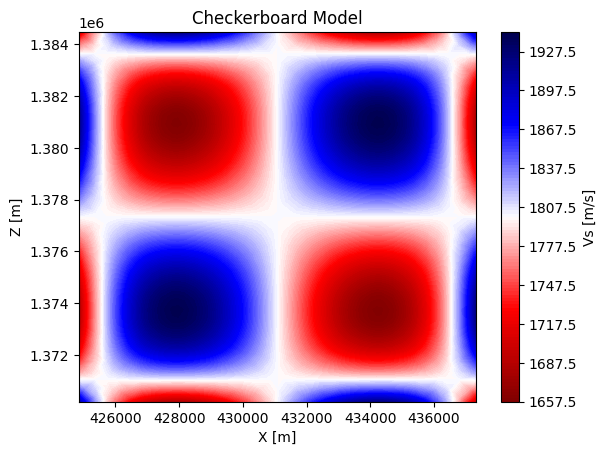

In [20]:
plot_checkerboard(chkbd_x, chkbd_y, chkbd_vs, label="Vs [m/s]")

# Write the interface file based on our domain made here

In [21]:
%cd /home/scoped/work/kernels

/home/scoped/work/kernels


In [22]:
with open('DATA/interfaces_Eastwind.dat', "r") as f:
    lines = f.readlines()

lines[7] = ' '+str(xmin)+' '+str(ymin)+'\n'
lines[8] = ' '+str(xmax)+' '+str(ymin)+'\n'

lines[11] = ' '+str(xmin)+' '+str(ymax)+'\n'
lines[12] = ' '+str(xmax)+' '+str(ymax)+'\n'

lines[17] = ' '+str(ny)+'\n'

with open('DATA/interfaces_Eastwind.dat', "w") as output:
    output.writelines(lines)

# Write our detected sources into source files

In [57]:
with open('DATA/SOURCE_temp', "r") as f:
    lines = f.readlines()

In [58]:
for sn,(xs,ys) in enumerate(zip(mean_params_good[:,0], mean_params_good[:,1])):
    lines[2] = 'xs                              = '+str(xs)+'      # source location x in meters\n'
    lines[3] = 'zs                              = '+str(ys)+'       # source location z in meters (zs is ignored if source_surf is set to true, it is replaced with the topography height)\n'
    with open('DATA/SOURCE_EW_'+str(f"{sn:03}"), "w") as output:
        output.writelines(lines)

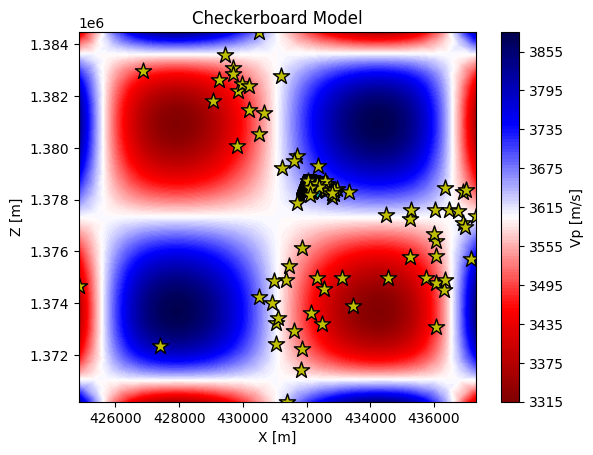

In [23]:
# Grab coordinates from STATIONS file
sta_x, sta_y = np.genfromtxt("DATA/STATIONS_checker", dtype=float, usecols=[2, 3]).T

# Grab coordinates from SOURCE files
ev_x, ev_z = [], []
for i in range(1, 83):
    source_file = f"DATA/SOURCE_EW_{i:0>3}"
    with open(source_file, "r") as f:
        lines = f.readlines()
    # Trying to break apart the following line
    # 'xs = 299367.72      # source location x in meters\n'
    xs = float(lines[2].split("=")[1].split("#")[0].strip())
    zs = float(lines[3].split("=")[1].split("#")[0].strip())
    
    ev_x.append(xs)
    ev_z.append(zs)
    
# Plot SOURCES and STATIONS on top of the checkerboard model
plot_checkerboard(chkbd_x, chkbd_y, chkbd_vp, label="Vp [m/s]")
plt.scatter(sta_x, sta_y, c="c", marker="v", s=40, edgecolor="k")
plt.scatter(ev_x, ev_z, c="y", marker="*", s=150, edgecolor="k")

Text(0.5, 1.0, 'SOURCES; N=82')

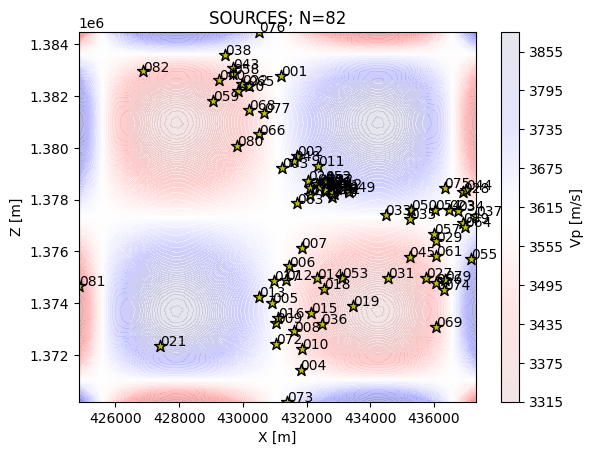

In [24]:
# Plot SOURCES next to source names
plot_checkerboard(chkbd_x, chkbd_y, chkbd_vp, label="Vp [m/s]", alpha=0.1)

for i, (x, z) in enumerate(zip(ev_x, ev_z)):
    plt.scatter(x, z, c="y", marker="*", edgecolor="k", s=80)
    plt.text(x, z, f"{i+1:0>3}", c="k")  # SOURCE numbering starts at 1
plt.title(f"SOURCES; N={len(ev_x)}")

Text(0.5, 1.0, 'STATIONS; N=351')

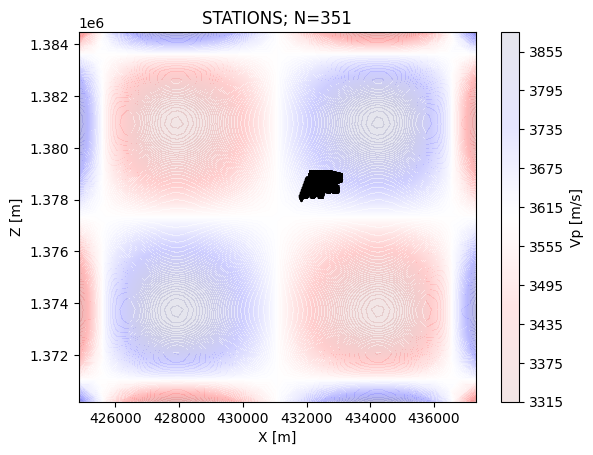

In [61]:
# Plot STATIONS next to source names
plot_checkerboard(chkbd_x, chkbd_y, chkbd_vp, label="Vp [m/s]", alpha=0.1)

for i, (x, z) in enumerate(zip(sta_x, sta_y)):
    plt.scatter(x, z, c="c", marker="v", s=8, edgecolor="k")
    plt.text(x, z, f"{i:0>3}", fontsize=9)
plt.title(f"STATIONS; N={len(sta_x)}")

Text(0.5, 1.0, 'SOURCE 01; STATION 01')

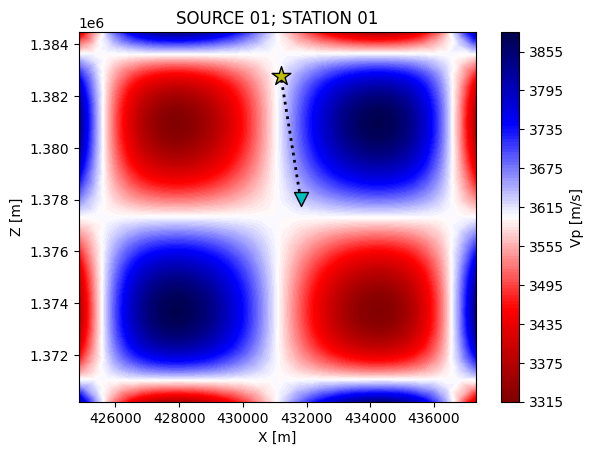

In [25]:
# Plot the experimental setup we'll use for Section 2
plot_checkerboard(chkbd_x, chkbd_y, chkbd_vp, label="Vp [m/s]")

# Plot SOURCE 1, STATION 1 and a connecting line
plt.plot((sta_x[0], ev_x[0]), (sta_y[0], ev_z[0]), c="k", ls=":", lw=2, zorder=1)
plt.scatter(sta_x[0], sta_y[0], c="c", marker="v", s=100, edgecolor="k")
plt.scatter(ev_x[0], ev_z[0], c="y", marker="*", edgecolor="k", s=200)

plt.title(f"SOURCE 01; STATION 01")

In [2]:
%cd /home/scoped/work/kernels

/home/scoped/work/kernels


# Make the parameter file

In [5]:
# We use SOURCE 1 as our preferred event
! cp -f DATA/SOURCE_EW_001 DATA/SOURCE

# We take the first line of the STATIONS file as our single station
! head -1 DATA/STATIONS_checker > DATA/STATIONS

# Copy the Parameter file and make some adjustments 
! cp -f DATA/Par_file_Eastwindrec_checker_updated DATA/Par_file

# Set parameters 
! seisflows sempar -P DATA/Par_file NSTEP 10000  # to match homogeneous halfspace Par_file
! seisflows sempar -P DATA/Par_file save_model binary
! seisflows sempar -P DATA/Par_file setup_with_binary_database 1

# Ensure that SPECFEM can find the checkerboard model by naming it correctly
! cp -f DATA/model_velocity_eastwind.dat_checker DATA/proc000000_model_velocity.dat_input

# Run Meshfem and SPECFEM SPECFEM2D 
! mpirun -n 1 bin/xmeshfem2D > OUTPUT_FILES/output_mesher.txt
! mpirun -n 1 bin/xspecfem2D > OUTPUT_FILES/output_solver.txt

# Rename the OUTPUT_FILES so that our next run doesn't overwrite files
! mv OUTPUT_FILES OUTPUT_FILES_EASTWIND

# Print the log message when the simulation is finished
! tail OUTPUT_FILES_EASTWIND/OUTPUT_FILES/output_solver.txt

NSTEP: 4800 -> 10000
SAVE_MODEL: default -> binary
setup_with_binary_database: 0 -> 1
 -------------------------------------------------------------------------------
 Program SPECFEM2D: 
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Eastwind
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 D a t e : 24 - 02 - 2026                                 T i m e  : 20:52:55
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------


OUTPUT_FILES_EASTWIND/OUTPUT_FILES/EW.C0000.BXY.semd


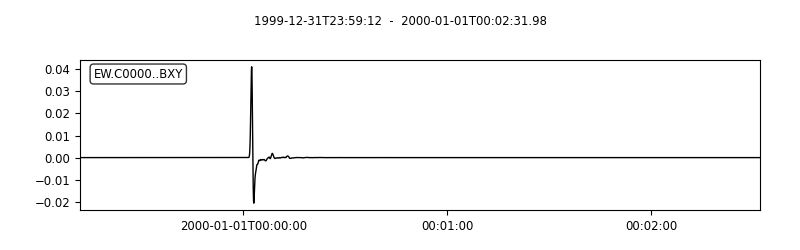

In [10]:
# SPECFEM has generated one synthetic seismogram
! ls OUTPUT_FILES_EASTWIND/OUTPUT_FILES/*semd

# We can look at this 'data' waveform using SeisFlows plot
! seisflows plotst OUTPUT_FILES_EASTWIND/OUTPUT_FILES/EW.C0000.BXY.semd --savefig OUTPUT_FILES_EASTWIND/EW.C0000.BXY.png
Image("EW.C0000.BXY.png")

In [ ]:
# The SOURCE and STATIONS files should remain the same,
# we only want to tell SPECFEM to use the homogeneous halfspace model
! cp -f DATA/Par_file_Eastwindrec_checker_updated DATA/Par_file

# Set some Par_file parameters to match the previous run
! seisflows sempar -P DATA/Par_file use_existing_stations .true.
! seisflows sempar -P DATA/Par_file save_model binary
! seisflows sempar -P DATA/Par_file setup_with_binary_database 1
! seisflows sempar -P DATA/Par_file save_forward .true.

# Run SPECFEM with the homogeneous halfspace model, defined in the Par_file
! rm -r OUTPUT_FILES_EASTWIND/OUTPUT_FILES
! mkdir OUTPUT_FILES
! mpirun -n 1 bin/xmeshfem2D > OUTPUT_FILES/output_mesher.txt
! mpirun -n 1 bin/xspecfem2D > OUTPUT_FILES/output_solver.txt

# Copy the OUTPUT_FILES so that our subsequent run doesn't overwrite files
# We do this because the adjoint simulation will require DATABASE files located within
# Rename the OUTPUT_FILES so that our next run doesn't overwrite files
! mv OUTPUT_FILES OUTPUT_FILES_EASTWIND

# Print the log message when the simulation is finished
! tail OUTPUT_FILES_EASTWIND/OUTPUT_FILES/output_solver.txt

use_existing_STATIONS: .true. -> .true.
SAVE_MODEL: default -> binary
setup_with_binary_database: 0 -> 1
SAVE_FORWARD: .false. -> .true.
rm: cannot remove 'OUTPUT_FILES': No such file or directory
mv: cannot move 'OUTPUT_FILES' to 'OUTPUT_FILES_EASTWIND/OUTPUT_FILES': File exists
 -------------------------------------------------------------------------------
 Program SPECFEM2D: 
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Eastwind
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 D a t e : 24 - 02 - 2026                                 T i m e  : 20:52:55
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------


In [18]:
# Look at the resulting outputs of the `save_forward` parameter
! diff -qr OUTPUT_FILES_INIT/ OUTPUT_FILES_TRUE/ | grep 'Only'

Only in OUTPUT_FILES_INIT/: absorb_elastic_bottom000000.bin
Only in OUTPUT_FILES_INIT/: absorb_elastic_left000000.bin
Only in OUTPUT_FILES_INIT/: absorb_elastic_right000000.bin
Only in OUTPUT_FILES_INIT/: absorb_elastic_top000000.bin
Only in OUTPUT_FILES_INIT/: lastframe_elastic000000.bin


OUTPUT_FILES_INIT/AA.S000000.BXY.semd


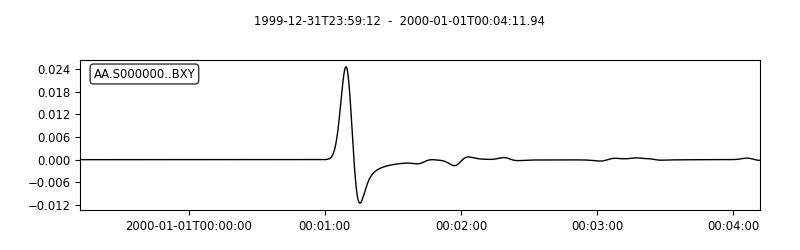

In [19]:
# Again we can look at the waveform. We will compare in the next section
! ls OUTPUT_FILES_INIT/*semd

! seisflows plotst OUTPUT_FILES_INIT/AA.S000000.BXY.semd --savefig AA.S000000.BXY.png
Image("AA.S000000.BXY.png")

In [20]:
! head OUTPUT_FILES/AA.S000000.BXY.semd

  -48.000000000000000          0.0000000000000000     
  -47.939999999999998          0.0000000000000000     
  -47.880000000000003          0.0000000000000000     
  -47.820000000000000          0.0000000000000000     
  -47.759999999999998          0.0000000000000000     
  -47.700000000000003          0.0000000000000000     
  -47.640000000000001          0.0000000000000000     
  -47.579999999999998          0.0000000000000000     
  -47.520000000000003          0.0000000000000000     
  -47.460000000000001          0.0000000000000000     


# Grab the real data

In [17]:
with open('/home/scoped/eastwind_v2/auto_picked_events/auto_picked_events.pkl', 'rb') as f:
    # Serialize and write the data to the file
    all_picks = pkl.load(f)

event_num = 1

event_datetime = datetime.datetime.fromtimestamp(np.mean(all_picks['Event '+str(event_num)][1]), tz=datetime.timezone.utc)
wanted_file_str = 'Eastwind_decimator_2024-12-'+str(event_datetime.day)+'_'+event_datetime.strftime("%H")+"."+event_datetime.strftime("%M")+".00_UTC.h5"

file = '/1-fnp/petasaur/p-jbod1/antarctica2425/incoming/'+wanted_file_str

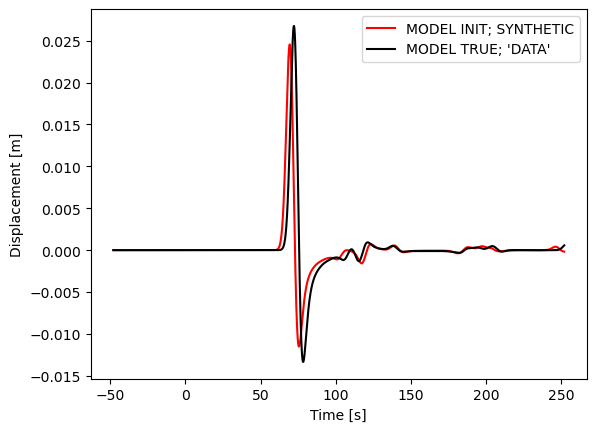

In [21]:
# Read in the two-column ASCII files using NumPy where - t=time; d=data
t_init, d_init = np.loadtxt("OUTPUT_FILES_INIT/AA.S000000.BXY.semd").T
t_true, d_true = np.loadtxt("OUTPUT_FILES_TRUE/AA.S000000.BXY.semd").T

# Plot both waveforms using Matplotlib
plt.plot(t_init, d_init, c="r", label="MODEL INIT; SYNTHETIC")
plt.plot(t_true, d_true, c="k", label="MODEL TRUE; 'DATA'")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.legend()
plt.show()

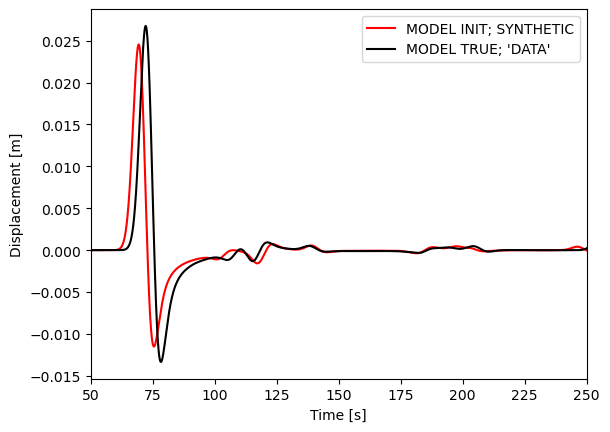

In [22]:
# Zoom in on waveform figure ignoring T<50s
plt.plot(t_init, d_init, c="r", label="MODEL INIT; SYNTHETIC")
plt.plot(t_true, d_true, c="k", label="MODEL TRUE; 'DATA'")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.xlim((50,250))
plt.legend()
plt.show()

In [23]:
# Integrate using scipy
dt = t_true[1] - t_true[0]  # dt represents the time step
misfit = 1/2 * simpson((d_true - d_init)**2, dx=dt)

print(f"misfit={misfit:.3E}")

misfit=1.453E-03


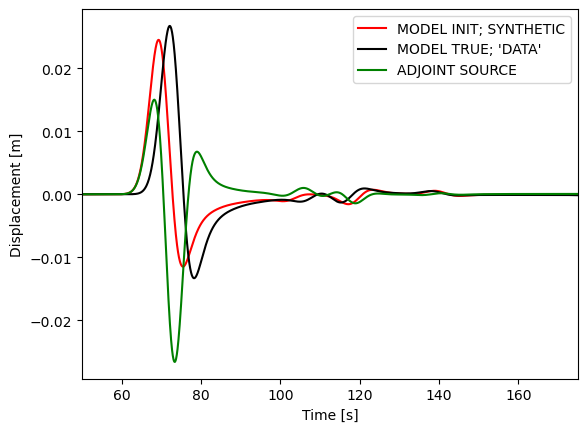

In [24]:
# Calculate the adjoint source using data and synthetic
d_adj = d_init - d_true

# Plot both waveforms using Matplotlib
plt.plot(t_init, d_init, c="r", label="MODEL INIT; SYNTHETIC")
plt.plot(t_true, d_true, c="k", label="MODEL TRUE; 'DATA'")
plt.plot(t_init, d_adj, c="g", label="ADJOINT SOURCE")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.xlim([50, 175])
plt.legend()
plt.show()

In [25]:
%cd /home/scoped/work/kernels

/home/scoped/work/kernels


In [26]:
# Make the requisite SEM/ directory
! mkdir SEM/

# Generate the two-column (time, data) format required
adjoint_source = np.vstack((t_init, d_adj)).T

# Save the .adj file as an ASCII file
np.savetxt("SEM/AA.S000000.BXY.adj", adjoint_source)
! head SEM/AA.S000000.BXY.adj

-4.800000000000000000e+01 0.000000000000000000e+00
-4.793999999999999773e+01 0.000000000000000000e+00
-4.788000000000000256e+01 0.000000000000000000e+00
-4.782000000000000028e+01 0.000000000000000000e+00
-4.775999999999999801e+01 0.000000000000000000e+00
-4.770000000000000284e+01 0.000000000000000000e+00
-4.764000000000000057e+01 0.000000000000000000e+00
-4.757999999999999829e+01 0.000000000000000000e+00
-4.752000000000000313e+01 0.000000000000000000e+00
-4.746000000000000085e+01 0.000000000000000000e+00


In [27]:
# Set the parameter file for an adjoint simulation
! seisflows sempar -P DATA/Par_file simulation_type 3
! seisflows sempar -P DATA/Par_file save_ASCII_kernels .false.

! mpirun -n 1 bin/xspecfem2D > OUTPUT_FILES/output_adjsolver.txt

# The adjoint solver also produces an informative log file
! tail OUTPUT_FILES/output_adjsolver.txt

# We can check this was an adjoint simulation because SPECFEM considers adjoint sources
! echo
! head -347 OUTPUT_FILES/output_adjsolver.txt | tail -n 5

SIMULATION_TYPE: 1 -> 3
save_ASCII_kernels: .true. -> .false.
 -------------------------------------------------------------------------------
 Program SPECFEM2D: 
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Tape-Liu-Tromp (GJI 2007)
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 D a t e : 19 - 02 - 2026                                 T i m e  : 00:44:21
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------


 adjoint sources:
   adjoint source type:           1
   reading ASCII adjoint source files
   number of adjoint sources =            1


In [28]:
# Copy over the Model files so SeisFlows has access to coordinate information
! cp -r DATA/*.bin OUTPUT_FILES

# Rename alpha and beta kernels
! cp OUTPUT_FILES/proc000000_alpha_kernel.bin OUTPUT_FILES/proc000000_vp_kernel.bin 
! cp OUTPUT_FILES/proc000000_beta_kernel.bin OUTPUT_FILES/proc000000_vs_kernel.bin 

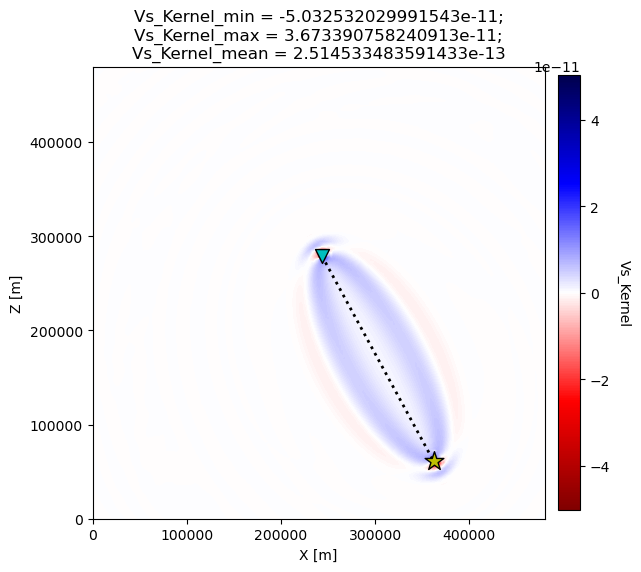

In [29]:
# Use SeisFlows to visualize the kernel
m = Model(path="OUTPUT_FILES")
m.plot2d("vs_kernel", show=False)

# NOTE: The below code snippet is repeated from Section 1, make sure that has been run
# Plot SOURCE 1, STATION 1 and a connecting line
plt.plot((sta_x[0], ev_x[0]), (sta_z[0], ev_z[0]), c="k", ls=":", lw=2, zorder=1)
plt.scatter(sta_x[0], sta_z[0], c="c", marker="v", s=100, edgecolor="k")
plt.scatter(ev_x[0], ev_z[0], c="y", marker="*", edgecolor="k", s=200)

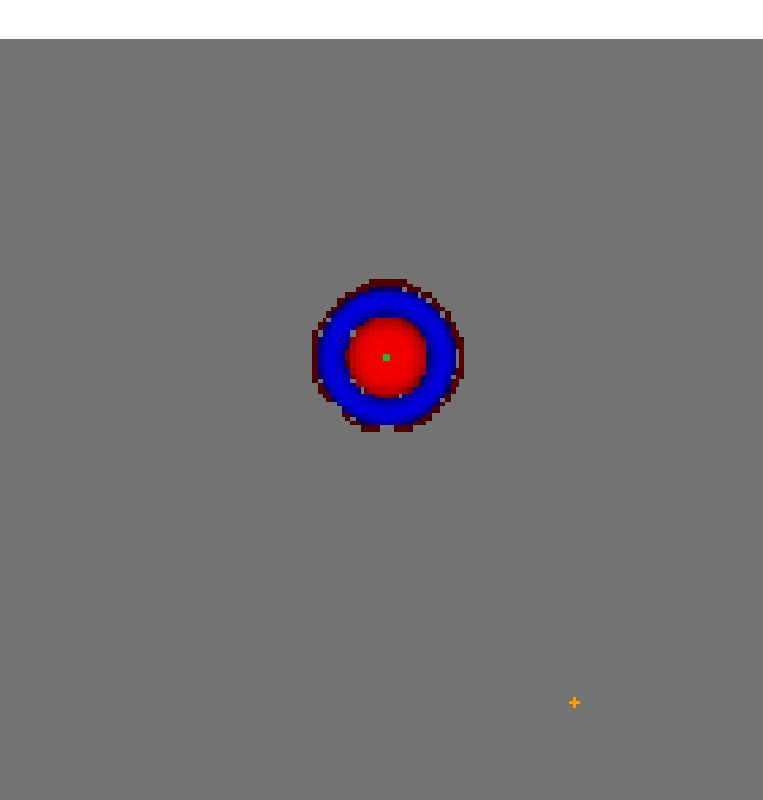

In [30]:
Image("OUTPUT_FILES/adjoint_image000000200.jpg")

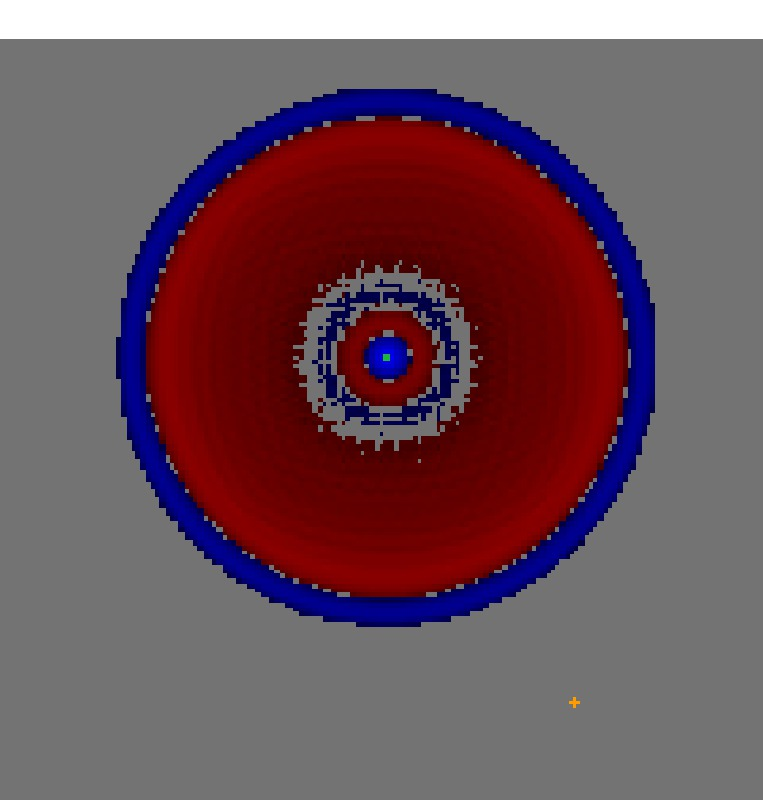

In [31]:
Image("OUTPUT_FILES/adjoint_image000000800.jpg")

 Running XSMOOTH_SEM on           1 processors
 command line arguments:
   smoothing sigma_h , sigma_v                :    5000.00000       5000.00000    
   smoothing scalelengths horizontal, vertical:    14142.1357       14142.1357    
   input dir : OUTPUT_FILES/
   output dir: OUTPUT_FILES/


 Scaling values: min/max =    39263216.0       157106752.    
 written: OUTPUT_FILES//proc000000_vs_kernel_smooth.bin

  Min / Max data value before smoothing =    5.33470852E-19   5.03253203E-11 for vs_kernel
  Min / Max data value after smoothing  =    4.77881162E-19   6.47305820E-12 for vs_kernel
 Computation time with CPU:   17.9555626    
OUTPUT_FILES/proc000000_alpha_kernel.bin
OUTPUT_FILES/proc000000_beta_kernel.bin
OUTPUT_FILES/proc000000_bulk_beta_kernel.bin
OUTPUT_FILES/proc000000_bulk_c_kernel.bin
OUTPUT_FILES/proc000000_kappa_kernel.bin
OUTPUT_FILES/proc000000_mu_kernel.bin
OUTPUT_FILES/proc000000_rho_kernel.bin
OUTPUT_FILES/proc000000_rhop_kernel.bin
OUTPUT_FILES/proc000000_vp_ker

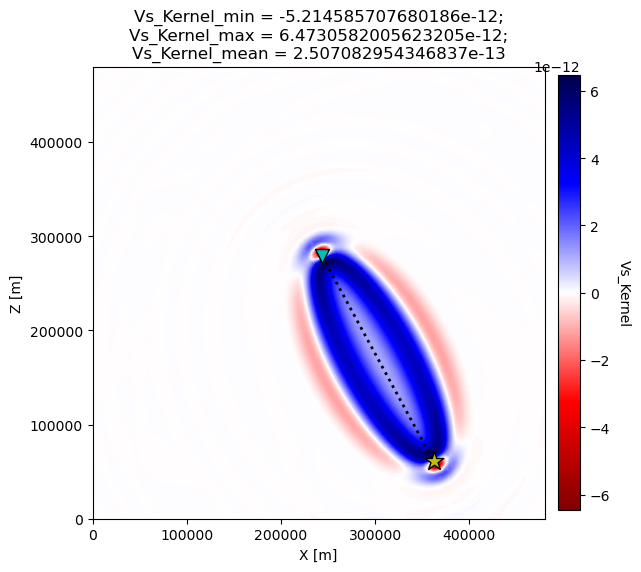

In [32]:

# Run the smoothinig operation
! mpirun -n 1 bin/xsmooth_sem 5000 5000 vs_kernel OUTPUT_FILES/ OUTPUT_FILES/ .false.

# Smoothed kernels are renamed <KERNEL_NAMEL>_smooth
! ls OUTPUT_FILES/*kernel*.bin

# Rename kernel files so we can plot the smooth version with SeisFlows
! mv OUTPUT_FILES/proc000000_vs_kernel.bin OUTPUT_FILES/proc000000_vs_kernel_raw.bin
! mv OUTPUT_FILES/proc000000_vs_kernel_smooth.bin OUTPUT_FILES/proc000000_vs_kernel.bin

# Use SeisFlows to visualize the kernel
m = Model("OUTPUT_FILES")
m.plot2d("vs_kernel", show=False)

# Plot source and receiver on the kernel figure
plt.plot((sta_x[0], ev_x[0]), (sta_z[0], ev_z[0]), c="k", ls=":", lw=2, zorder=1)
plt.scatter(sta_x[0], sta_z[0], c="c", marker="v", s=100, edgecolor="k")
plt.scatter(ev_x[0], ev_z[0], c="y", marker="*", edgecolor="k", s=200)